In [95]:
import os
from pyscf import gto
from pyscf.dft import numint
from pyscf.lib import param
from datetime import datetime

import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.utils.grids import cubical_grid, cubical_sampling, \
     CubicalGrid, spherical_grid, spherical_radial_sampling
import equiv_dens.utils.base as utils
import equiv_dens.utils.orbitals as orbitals
from equiv_dens.utils.misc import generate_id

from functools import partial
from argparse import Namespace
from equiv_dens.training import density_errors
import matplotlib.pyplot as plt
import numpy as np
from equiv_dens.training import model_loader
import equiv_dens.utils.cubetools as cubetools

%load_ext autoreload
%autoreload 2
%cd /home/mihail/Documents/workspace/equiv_dens/

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/mihail/Documents/workspace/equiv_dens


In [96]:
main_args = Namespace()

main_args.args_file = "args/resorcinol_all_005.txt"
# main_args.args_file = "args/CO_dens_001.txt"
# main_args.args_file = "args/h2o_dens_002.txt"
# main_args.args_file = "args/ethanethiol_all_006_test.txt"
main_args.ref_np_load_file = None
main_args.ref_dens_load_file = None
# main_args.save_file = 'CO_dens_001.txt'
# main_args.save_file = 'h2o_dens_002.txt'
main_args.res_load_file = 'datasets/resorcinol_all_005_test.pt'
main_args.save_file = 'resorcinol_all_005'
# main_args.res_load_file = 'datasets/ethanethiol_all_006_test.pt'
# main_args.save_file = 'ethanethiol_all_006_test'
# main_args.save_file = 'resorcinol_all_005'
main_args.df_error = True
main_args.use_gpu = False
main_args.num_samples = 100
main_args.make_plots = True

df_losses = None

In [99]:
args, hyperparam_args = parse_command_line_arguments(arg_file=main_args.args_file)

# print('type dtype', type(args.dtype))
args.fix_arguments = True
# print('args np dir', args.np_dataset)
# args.restart = None
# args.pred_radial_coeffs = False

if args.restart is None:
    # generate "unique" id for the run (very unlikely that two runs will have the same ID)
    model_code = generate_id()
    directory = os.path.join(args.save_dir, datetime.utcnow().strftime("%Y-%m-%d_") +
                             model_code)  # generate directory name
    # create directories
    # if not os.path.exists(directory):
    #     os.makedirs(directory)
    # # write command line arguments to file (useful for reproducibility)
    # with open(os.path.join(directory, 'args.txt'), 'w') as f:
    #     for key in args.__dict__.keys():
    #         # special case for list input
    #         if isinstance(args.__dict__[key], list):
    #             for entry in args.__dict__[key]:
    #                 f.write('--' + key + '=' + str(entry) + "\n")
    #         else:
    #             f.write('--' + key + '=' + str(args.__dict__[key]) + "\n")
    checkpoint = None
    latest_checkpoint = 0
    step = 0
    restore = False
    data_split_indices = None
    # restarts run from latest checkpoint
else:
    # no restart directory specifie
    directory = args.restart
    # load latest checkpoint
    checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
    checkpoint = torch.load(os.path.join(
        checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
    latest_checkpoint = checkpoint['step']
    model_code = checkpoint['ID']  # load ID
    step = checkpoint['step']
    for arg in vars(checkpoint['args']):
        if args.fix_arguments:
            if arg in hyperparam_args:
                # print('loading hyperparam arg', arg)
                setattr(args, arg, getattr(checkpoint['args'], arg))
        else:
            # print('loading all arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    restore = True
    data_split_indices = checkpoint['data_split_indices']

args.df_weight = 1.0

print('model code:', model_code)

# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False

# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.verbose = 0
args.use_gpu = False
print('args use gpu', args.use_gpu)
args.cube_grid = False
args.radii_adjust = True
args.expansion_constraint = None
if args.cube_grid:
    args.cube_origin = -2
    args.cube_extent = 4
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    args.spherical_grid_level = 1
    grid_fn = partial(spherical_grid, level=args.spherical_grid_level)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None
    rotate = False

required_properties = ['energy', 'forces', 'df_coeffs', 'density', 'dipole_moment']

if main_args.ref_np_load_file is not None:
    args.np_dataset_test = main_args.ref_np_load_file
if main_args.ref_dens_load_file is not None:
    args.dens_dataset_test = main_args.ref_dens_load_file

args.np_dataset_test = "datasets/resorcinol_md_traj_dft_augccpvdz.npy"
args.dens_dataset_test = "datasets/resorcinol_md_traj_dft_augccpvdz_df_augccpvqzjkfit.npy"

dataset = AtomsDensityData(np_path=args.np_dataset_test, density_path=args.dens_dataset_test,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000000000000000,
                           required_properties=required_properties,
                           center_positions=True,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=grid_fn,
                           pyscf_grid=args.pyscf_grid,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           cutoff=args.cutoff,
                           df_loss_weights=args.df_loss_weights,
                           projected_density=args.projected_density,
                           radii_adjust=args.radii_adjust,
                           calc_data=True,
                           )

print('dataset length', len(dataset))
print('sample pos shape', dataset.get_properties([0])['positions'].shape)
print('sample dens shape', dataset.get_properties([0])['density'].shape)
if main_args.num_samples < 1:
    main_args_num_samples = len(dataset)
print('num samples', main_args.num_samples)
print('args use gpu', args.use_gpu)

model code: 7ThoNt6y
args use gpu True
loading density fromdatasets/resorcinol_combo_kmeansidx-1000_train_pyscf_augccpvqzjkfit.npy...
loading atoms fromdatasets/resorcinol_combo_kmeansidx-1000_train.npy...
args use gpu False
finished init
dataset length 100
dens diff dataset sample tensor(0.)
sample pos shape torch.Size([1, 14, 3])
dens diff dataset sample tensor(0.)
sample dens shape torch.Size([1, 56032])
num samples 100
args use gpu False


In [100]:
df_losses = None
if main_args.df_error:
    # df_losses = {'dens_mae': [], 'dens_rmse': [], 'dpm_mae': [],
    #              'dpm_rmse': [], 'kl_loss': [],
    #              'dpm_mag': [], 'dpm_ang': [], 'lda_mae': [],
    #              'coulomb': [], 'coulomb_int': [], 'mae_23': [], 'mae_43': [],
    #              'lda_23_mae': [], 'dpm_coord_rmse': [],
    #              'dpm_pos_coord_rmse': [], 'dpm_neg_coord_rmse': [],
    #              'dpm_int_rmse': []}

    dataset_df = AtomsDensityData(np_path=args.np_dataset_test, density_path=args.dens_dataset_test,
                                  orbitals_path=args.orbitals_file,
                                  density_n_samp=10000000000000000000000,
                                  required_properties=required_properties,
                                  center_positions=True,
                                  radial_coeffs_file=args.radial_coeffs_file,
                                  dtype=args.dtype,
                                  grid_fn=grid_fn,
                                  pyscf_grid=args.pyscf_grid,
                                  sampling_fn=sampling_fn,
                                  grid_extent=grid_extent,
                                  grid_origin=grid_origin,
                                  cutoff=args.cutoff,
                                  df_loss_weights=args.df_loss_weights,
                                  projected_density=True,
                                  radii_adjust=args.radii_adjust,
                                  )

finished init


In [77]:
test_indices = checkpoint['data_split_indices']['test']
print(test_indices)

[]


In [102]:
model = model_loader.load_model(args, dataset)
idx = 4
samp = dataset.get_properties([idx])
samp_df = dataset_df.get_properties([idx])

res = model(samp)

print('samp df_coeffs', samp_df['df_coeffs'].shape)
print('res df_coeffs', res['df_coeffs'].shape)

# print('res_radial width', res['radial_width'])
# print('dataset radial coeffs', dataset.radial_coeffs)
print('res density integral', torch.sum(res['density'] * res['coord_weights'], dim=1))
print('density integral', torch.sum(samp['density'] * samp['coord_weights'], dim=1))
print('density integral', torch.sum(samp_df['density'] * samp_df['coord_weights'], dim=1))
print('density error', torch.sum(torch.abs(res['density'] - samp['density']) * samp['coord_weights'], dim=1) / torch.sum(samp['atom_numbers']))
print('density df error', torch.sum(torch.abs(samp_df['density'] - samp['density']) * samp['coord_weights'], dim=1) / torch.sum(samp['atom_numbers']))

cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in hartree
args energy_unit_out kcal
conversions in <function hartree_to_kcal at 0x7f40aec43880>
conversions out <function kcal_to_kcal at 0x7f40aec413f0>
self.pred_radial_coeffs True
building spherical harmonic energy model
density_weight 1.0
dipole_moment_weight 0.0
force props ['energy']
no force props ['density']
dens diff dataset sample tensor(0.)
dens diff dataset df tensor(0.)
self normalize en 2
fs norm start : [0.9820410013198853, 0.9308622479438782, 0.914427638053894, 0.8938924074172974, 0.9074057340621948, 0.9335542917251587]
samp df_coeffs torch.Size([1, 1592])
res df_coeffs torch.Size([1, 1592])
res density integral tensor([58.0009], grad_fn=<SumBackward1>)
density integral tensor([58.0002])
density integral tensor([58.0002])
density error tensor([0.0011], grad_fn=<DivBackward0>)


In [94]:
basis = 'augccpvdz'
auxbasis = 'augccpvqzjkfit'
dens = orbitals.sample_density(samp, dataset.coeffs[idx]['mo_coeff'], dataset.coeffs[idx]['mo_occ'], basis=basis)
print('dens diff to samp', torch.sum(torch.abs(samp['density'] - dens) * samp['coord_weights'], dim=1) / torch.sum(samp['atom_numbers']))
ml_df_coeffs, auxmol_ext = orbitals.ml_basis_to_df_coeffs(res, basis, auxbasis,
                                                          mo_coeff=samp['mo_coeff'][0],
                                                          mo_occ=samp['mo_occ'][0])
dens = orbitals.sample_projected_density(samp, torch.tensor(ml_df_coeffs).unsqueeze(0),
                                         auxbasis, auxmol=auxmol_ext,)

dens diff to samp tensor([5.9520e-05])


In [ ]:
# atoms = np.load('md_logs/2022-12-23_pJuMyc8e/simulation_-ethanethiol_cluster_all_001_compressed_0.npy', allow_pickle=True).item()
# print(atoms['positions'].shape)
# print(atoms['atom_numbers'].shape)
# idx = -1
# atoms['positions'] = atoms['positions'][[idx]]
# atoms = utils.model_input_from_atoms(atoms, args.use_gpu, density_expansion=True, pyscf_grid=args.pyscf_grid,
#                                      grid_spec=dataset.grid_spec, grid_sampling_fn=dataset.sampling_fn,
#                                      cutoff=args.cutoff)
# print(atoms['positions'].shape)
# print(atoms['atom_numbers'].shape)
# atoms_samp = {'positions': samp['positions'], 'atom_numbers': samp['atom_numbers']}
# atoms_samp = utils.model_input_from_atoms(atoms_samp, args.use_gpu, density_expansion=True, pyscf_grid=args.pyscf_grid,
#                                           grid_spec=dataset.grid_spec, grid_sampling_fn=dataset.sampling_fn,
#                                           cutoff=args.cutoff)

In [ ]:
# res  = model(atoms)
# print('res density integral', torch.sum(res['density'] * res['coord_weights'], dim=1))
# res_samp = model(atoms_samp)
# print('res_samp density integral', torch.sum(res_samp['density'] * res_samp['coord_weights'], dim=1))

In [13]:
ml_dpm_errors = {'dens_mae': [], 'dpm_norm': [],
                 'dpm_point_abs': [], 'dpm_point_norm': [],
                 'dpm_r_norm': [], 'dpm_ang': [], 'dpm_mag': []}
df_dpm_errors = {'dens_mae': [], 'dpm_norm': [],
                 'dpm_point_abs': [], 'dpm_point_norm': [],
                 'dpm_r_norm': [], 'dpm_ang': [], 'dpm_mag': []}
ml_df_dpm_errors = {'dens_mae': [], 'dpm_norm': [],
                    'dpm_point_abs': [], 'dpm_point_norm': [],
                    'dpm_r_norm': [], 'dpm_ang': [], 'dpm_mag': []}
for i in range(100):
    print('i', i)
    samp = dataset.get_properties([i])
    samp_df = dataset_df.get_properties([i])

    center_of_mass = torch.sum(samp['batch_positions'] * samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)\
        / torch.sum(samp['batch_atom_numbers'].unsqueeze(-1), dim=1, keepdim=True)

    res = model(samp)
    distance_from_com = torch.norm(samp['coords'] - center_of_mass, dim=2)

    density_mae = torch.sum(torch.abs(samp['density'] - res['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
    # density_err = torch.abs(samp['density'] - res['density']) * samp['coord_weights']
    res = orbitals.calc_dipole_moment(res)
    dpm_err = torch.norm(samp['dipole_moment'] - res['dipole_moment'])
    # dpm_point_err = ((res['density'] - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)
    dpm_point_abs_err = density_errors.dipole_pointwise_abs_loss(res['density'], samp['density'], samp['coords'], samp['coord_weights'])
    dpm_point_norm_err = density_errors.dipole_pointwise_int_loss(res['density'], samp['density'], samp['coords'], samp['coord_weights'])
    dpm_point_err_r_norm = torch.abs(torch.sum(((res['density'] - samp['density']) * samp['coord_weights']) * torch.norm(samp['coords'] - center_of_mass, dim=-1), dim=1))
    dpm_mag_err = torch.abs(torch.norm(samp['dipole_moment']) - torch.norm(res['dipole_moment']))
    dpm_ang_error = (180 / torch.pi) * torch.acos(torch.mean(torch.sum(res['dipole_moment']*samp['dipole_moment']) /
                                                  (torch.norm(res['dipole_moment']) * torch.norm(samp['dipole_moment']))))
    ml_dpm_errors['dens_mae'].append(density_mae.detach().cpu())
    ml_dpm_errors['dpm_norm'].append(dpm_err.detach().cpu())
    ml_dpm_errors['dpm_point_abs'].append(dpm_point_abs_err.detach().cpu())
    ml_dpm_errors['dpm_point_norm'].append(dpm_point_norm_err.detach().cpu())
    ml_dpm_errors['dpm_r_norm'].append(dpm_point_err_r_norm.detach().cpu())
    ml_dpm_errors['dpm_ang'].append(dpm_ang_error.detach().cpu())
    ml_dpm_errors['dpm_mag'].append(dpm_mag_err.detach().cpu())
    # print('density_mae', density_mae)
    # print('dpm norm error', dpm_err)
    # print('dpm pointwise error', dpm_point_err.sum())
    # print('dpm point abs error', dpm_point_abs_err)
    # print('dpm point norm error', dpm_point_norm_err)
    # print('dpm point r norm error', dpm_point_err_r_norm)
    # print('')

    density_df_mae = torch.sum(torch.abs(samp['density'] - samp_df['density']) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
    # density_df_err = torch.abs(samp['density'] - samp_df['density']) * samp['coord_weights']
    dpm_df_err = torch.norm(samp['dipole_moment'] - samp_df['dipole_moment'])
    # dpm_df_point_err = ((samp_df['density'] - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)
    dpm_df_point_abs_err = density_errors.dipole_pointwise_abs_loss(samp_df['density'], samp['density'], samp['coords'], samp['coord_weights'])
    dpm_df_point_err_r_norm = torch.abs(torch.sum(((samp_df['density'] - samp['density']) * samp['coord_weights']) * torch.norm(samp['coords'] - center_of_mass, dim=-1), dim=1))
    dpm_df_point_norm_err = density_errors.dipole_pointwise_int_loss(samp_df['density'], samp['density'], samp['coords'], samp['coord_weights'])
    dpm_df_mag_err = torch.abs(torch.norm(samp['dipole_moment']) - torch.norm(samp_df['dipole_moment']))
    dpm_df_ang_error = (180 / torch.pi) * torch.acos(torch.mean(torch.sum(samp_df['dipole_moment']*samp['dipole_moment']) /
                                                     (torch.norm(samp_df['dipole_moment']) * torch.norm(samp['dipole_moment']))))
    df_dpm_errors['dens_mae'].append(density_df_mae.detach().cpu())
    df_dpm_errors['dpm_norm'].append(dpm_df_err.detach().cpu())
    df_dpm_errors['dpm_point_abs'].append(dpm_df_point_abs_err.detach().cpu())
    df_dpm_errors['dpm_point_norm'].append(dpm_df_point_norm_err.detach().cpu())
    df_dpm_errors['dpm_r_norm'].append(dpm_df_point_err_r_norm.detach().cpu())
    df_dpm_errors['dpm_ang'].append(dpm_df_ang_error.detach().cpu())
    df_dpm_errors['dpm_mag'].append(dpm_df_mag_err.detach().cpu())
    # print('density_df_mae', density_df_mae)
    # print('dpm df norm error', dpm_df_err)
    # print('dpm df pointwise error', dpm_df_point_err.sum())
    # print('dpm df point abs err', dpm_df_point_abs_err)
    # print('dpm df point norm error', dpm_df_point_norm_err)
    # print('dpm df point r norm error', dpm_df_point_err_r_norm)
    # print('')

    basis = 'augccpvdz'
    auxbasis = 'augccpvqzjkfit'
    ml_df_coeffs, auxmol_ext = orbitals.ml_basis_to_df_coeffs(res, basis, auxbasis,
                                                              mo_coeff=samp['mo_coeff'][0],
                                                              mo_occ=samp['mo_occ'][0])
    dens = orbitals.sample_projected_density(samp, torch.tensor(ml_df_coeffs).unsqueeze(0),
                                             auxbasis, auxmol=auxmol_ext,)
    # print(samp['atom_numbers'])
    # print('auxmol ext basis', auxmol_ext._bas)
    # print('auxmol ext env shape', auxmol_ext._env.shape)
    # #
    samp2 = dataset.get_properties([i])
    dpm = orbitals.calc_dipole_moment(samp2, density=dens, normalize_density=False, positive_density=False)['dipole_moment']
    # print('dpm', dpm)
    # print('samp dpm', samp['dipole_moment'])
    density_ml_df_mae = torch.sum(torch.abs(samp['density'] - dens) * samp['coord_weights']) / torch.sum(samp['atom_numbers'])
    # density_ml_df_err = torch.abs(samp['density'] - dens) * samp['coord_weights']
    dpm_ml_df_err = torch.norm(samp['dipole_moment'] - dpm)
    # dpm_ml_df_point_err = ((dens - samp['density']) * samp['coord_weights']).unsqueeze(-1) * (samp['coords'] - center_of_mass)
    dpm_ml_df_point_abs_err = density_errors.dipole_pointwise_abs_loss(dens, samp['density'], samp['coords'], samp['coord_weights'])
    dpm_ml_df_point_err_r_norm = torch.abs(torch.sum(((dens - samp['density']) * samp['coord_weights']) * torch.norm(samp['coords'] - center_of_mass, dim=-1), dim=1))
    dpm_ml_df_point_norm_err = density_errors.dipole_pointwise_int_loss(dens, samp['density'], samp['coords'], samp['coord_weights'])
    dpm_ml_df_mag_err = torch.abs(torch.norm(samp['dipole_moment']) - torch.norm(dpm))
    dpm_ml_df_ang_error = (180 / torch.pi) * torch.acos(torch.mean(torch.sum(dpm*samp['dipole_moment']) /
                                                        (torch.norm(dpm) * torch.norm(samp['dipole_moment']))))

    ml_df_dpm_errors['dens_mae'].append(density_ml_df_mae.detach().cpu())
    ml_df_dpm_errors['dpm_norm'].append(dpm_ml_df_err.detach().cpu())
    ml_df_dpm_errors['dpm_point_abs'].append(dpm_ml_df_point_abs_err.detach().cpu())
    ml_df_dpm_errors['dpm_point_norm'].append(dpm_ml_df_point_norm_err.detach().cpu())
    ml_df_dpm_errors['dpm_r_norm'].append(dpm_ml_df_point_err_r_norm.detach().cpu())
    ml_df_dpm_errors['dpm_ang'].append(dpm_ml_df_ang_error.detach().cpu())
    ml_df_dpm_errors['dpm_mag'].append(dpm_ml_df_mag_err.detach().cpu())
    # print('density_ml_df_mae', density_ml_df_mae)
    # print('dpm ml df norm error', dpm_ml_df_err)
    # print('dpm ml df pointwise error', dpm_ml_df_point_err.sum())
    # print('dpm ml df point abs err', dpm_ml_df_point_abs_err)
    # print('dpm ml df point norm error', dpm_ml_df_point_norm_err)
    # print('dpm ml df point r norm error', dpm_ml_df_point_err_r_norm)
    # print('')

print('ml_dpm_errors', ml_dpm_errors)
print('df_dpm_errors', df_dpm_errors)
print('ml_df_dpm_errors', ml_df_dpm_errors)
# np.save('results/resorcinol_ml_dpm_errors.npy', ml_dpm_errors, allow_pickle=True)
# np.save('results/resorcinol_df_dpm_errors.npy', df_dpm_errors, allow_pickle=True)
# np.save('results/resorcinol_ml_df_dpm_errors.npy', ml_df_dpm_errors, allow_pickle=True)

i 0
self normalize en 2
fs norm start : [0.9819777607917786, 0.931000828742981, 0.9141663908958435, 0.8938505053520203, 0.9074034094810486, 0.9335542321205139]


KeyboardInterrupt: 

In [67]:
ml_dpm_errors = np.load('results/resorcinol_ml_dpm_errors.npy', allow_pickle=True).item()
df_dpm_errors = np.load('results/resorcinol_df_dpm_errors.npy', allow_pickle=True).item()
ml_df_dpm_errors = np.load('results/resorcinol_ml_df_dpm_errors.npy', allow_pickle=True).item()

In [68]:
for key in ml_dpm_errors.keys():
    for i in range(len(ml_dpm_errors[key])):
        factor = 1
        if 'dpm' in key and 'ang' not in key:
            factor = 4.8
        ml_dpm_errors[key][i] = factor * float(ml_dpm_errors[key][i])
        df_dpm_errors[key][i] = factor * float(df_dpm_errors[key][i])
        ml_df_dpm_errors[key][i] = factor * float(ml_df_dpm_errors[key][i])

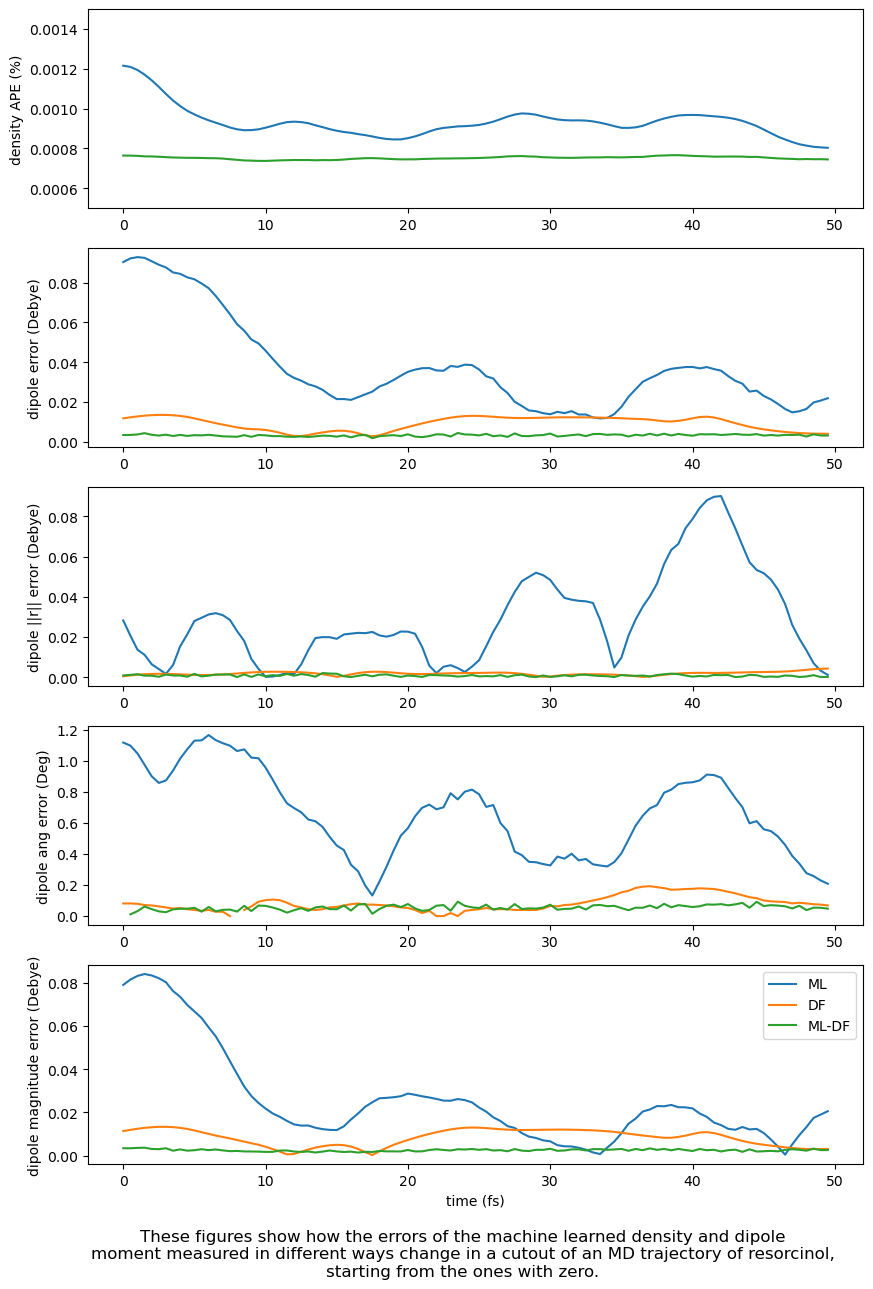

In [69]:
fig, axs = plt.subplots(5, 1, figsize=(10, 15))
keys = ['dens_mae', 'dpm_norm', 'dpm_r_norm', 'dpm_ang', 'dpm_mag']
labels = ['density APE (%)', 'dipole error (Debye)', 'dipole ||r|| error (Debye)', 'dipole ang error (Deg)', 'dipole magnitude error (Debye)']
for i, key in enumerate(keys):
    # print(key)
    # print(np.array(ml_dpm_errors[key]))
    # print(len(ml_dpm_errors[key]))
    axs[i].plot(np.arange(len(ml_dpm_errors[key]))/2, ml_dpm_errors[key], label='ML')
    axs[i].plot(np.arange(len(ml_dpm_errors[key]))/2, df_dpm_errors[key], label='DF')
    axs[i].plot(np.arange(len(ml_dpm_errors[key]))/2, ml_df_dpm_errors[key], label='ML-DF')
    axs[i].set_ylabel(labels[i])
    if i == 0:
        axs[i].set_ylim(0.0005, 0.0015)
axs[i].set_xlabel('time (fs)')
fig.text(0.5, 0.05,
         'These figures show how the errors of the machine learned density and dipole\n' + 
         'moment measured in different ways change in a cutout of an MD trajectory of resorcinol,\n' +
         'starting from the ones with zero.',
         ha='center', va='center', fontsize=12)
plt.legend()
plt.savefig('figures/resorcinol_md_dpm_errors.png', dpi=300)
plt.show()

In [71]:
for key in keys:
    print('ML', key, np.nanmean(ml_dpm_errors[key]))
    print('DF', key, np.nanmean(df_dpm_errors[key]))
    print('ML-DF', key, np.nanmean(ml_df_dpm_errors[key]))
    print('')

ML dens_mae 0.0009320756676606833
DF dens_mae 0.006199793950654567
ML-DF dens_mae 0.0007525050270429602

ML dpm_norm 0.03698968499153852
DF dpm_norm 0.009146576922386884
ML-DF dpm_norm 0.003228211894805516

ML dpm_r_norm 0.028916728684678678
DF dpm_r_norm 0.0018044833391904832
ML-DF dpm_r_norm 0.0007474418209435897

ML dpm_ang 0.6576272802054882
DF dpm_ang 0.08238008919388357
ML-DF dpm_ang 0.05472002622588371

ML dpm_mag 0.02518830728530884
DF dpm_mag 0.008300721645355223
ML-DF dpm_mag 0.0024313362295000475

